In [1]:
#Menghubungkan colab dengan google drive
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
#Memanggil data set lewat gdrive
path = "/content/gdrive/MyDrive/Praktikum-Tugas_MachineLearning/Praktikum6"

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [4]:
df = pd.read_csv(path + '/Data/heart.csv')


df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [6]:
df.info()
print("\nJumlah data:", len(df))
print("\nCek nilai kosong:\n", df.isnull().sum())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB

Jumlah data: 1025

Cek nilai kosong:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal     

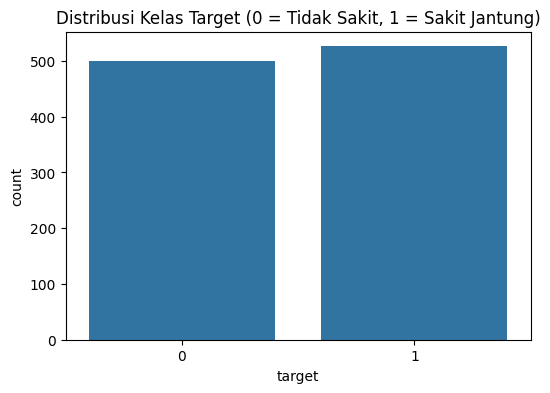

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x='target', data=df)
plt.title('Distribusi Kelas Target (0 = Tidak Sakit, 1 = Sakit Jantung)')
plt.show()


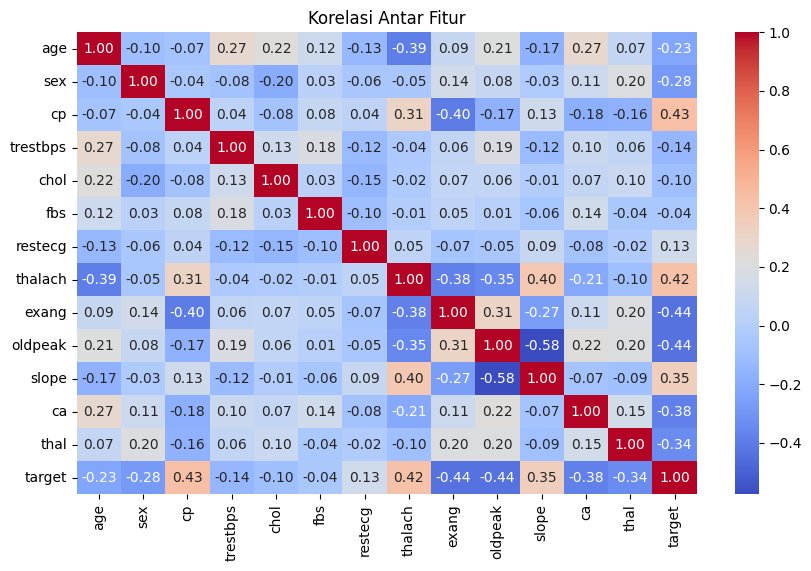

In [8]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Korelasi Antar Fitur')
plt.show()


In [9]:
X = df.drop(columns=['target'])
y = df['target']

# Split data 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [11]:
# Gunakan kernel RBF (paling umum)
svm_model = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)
svm_model.fit(X_train_scaled, y_train)


SVC(C=1, random_state=42)

In [12]:
y_pred = svm_model.predict(X_test_scaled)

print("Akurasi Model SVM:", round(accuracy_score(y_test, y_pred), 3))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nLaporan Klasifikasi:\n", classification_report(y_test, y_pred))


Akurasi Model SVM: 0.927

Confusion Matrix:
 [[91  9]
 [ 6 99]]

Laporan Klasifikasi:
               precision    recall  f1-score   support

           0       0.94      0.91      0.92       100
           1       0.92      0.94      0.93       105

    accuracy                           0.93       205
   macro avg       0.93      0.93      0.93       205
weighted avg       0.93      0.93      0.93       205



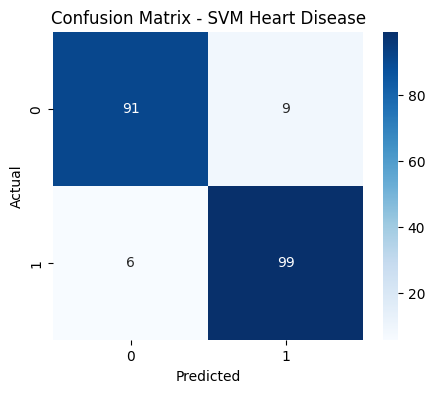

In [13]:
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - SVM Heart Disease")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [15]:
# Contoh data baru
data_baru = pd.DataFrame({
    'age': [52],
    'sex': [1],
    'cp': [0],
    'trestbps': [130],
    'chol': [240],
    'fbs': [0],
    'restecg': [1],
    'thalach': [160],
    'exang': [0],
    'oldpeak': [1.0],
    'slope': [2],
    'ca': [0],
    'thal': [2]
})

pred_baru = svm_model.predict(scaler.transform(data_baru))
print("Prediksi pasien baru:", "Sakit jantung" if pred_baru[0]==1 else "Tidak sakit jantung")


Prediksi pasien baru: Sakit jantung
